In [38]:
# comparison of different benchmark feature space
import pandas as pd
import numpy as np
from Benchmarks import get_dataset
import scipy.stats as stats
import matplotlib.pyplot as plt

def statistic(label):
    values=[]
    for i in range(10):
        values.append(np.sum(label[:,0]==i)/len(label)) 
    return values

In [28]:
# RGI
RGI_ela,label=get_dataset(0)

D:\Python39\lib\site-packages\numpy\core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [29]:
# RGF
RGF_ela,label=get_dataset(5)


In [30]:
# BBOB
BBOB_ela,label=get_dataset(1)



In [31]:
# BBOB_Affine
Affine_ela,label=get_dataset(2)


In [40]:
#MA-BBOB
MA_ela,label=get_dataset(6)

# 可接受baseline
# label[:,1+int(2*30):1+int((2+1)*30)]=label[:,1+int(2*30):1+int((2+1)*30)]-1000
accs=[]
record=[]
for a in range(10):
    acc=0
    for i in range(len(label)//100):
        if a==label[i,0]:
            acc+=1
        elif stats.ranksums(label[i,1+int(a*30):1+int((a+1)*30)],label[i,1+int(label[i,0]*30):1+int((label[i,0]+1)*30)])[1] > 0.05:
            acc+=1
            record.append(label[i,1+int(a*30):1+int((a+1)*30)])
            record.append(label[i,1+int(label[i,0]*30):1+int((label[i,0]+1)*30)])
            # print(i)
    print("可接受率",acc*100/len(label))
    accs.append(acc*100/len(label))
record=np.array(record)

可接受率 0.12239902080783353
可接受率 0.2039983680130559
可接受率 0.795593635250918
可接受率 0.4079967360261118
可接受率 0.14279885760913913
可接受率 0.12239902080783353
可接受率 0.11219910240718074
可接受率 0.12239902080783353
可接受率 0.1631986944104447
可接受率 0.11219910240718074


In [33]:
# Zigzag
Zigzag_ela,label=get_dataset(3)



In [34]:
# GPB
GPB_ela,label=get_dataset(4)



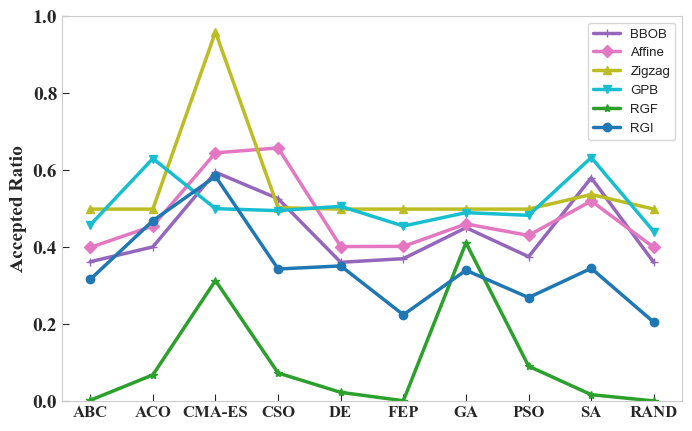

In [48]:
# acceptedAcc
RGI_accepted=[0.3162065275548422, 0.4685874799357945, 0.5837453183520599, 0.34322097378277155, 0.35122525414660244, 0.22424826110219367, 0.3399518459069021, 0.2690529695024077, 0.34497592295345103, 0.20480470840021403]
RGF_accepted=[0.0022997937743610784,0.06816243238282389,0.3132578252372675,0.07301035447056156,0.02279279182007623,0.0010797153870239805,0.4113067795329151,0.0907608754332358,0.016789574268222897,0.0005398576935119903]
BBOB_accepted=[0.3620527306967985, 0.4006591337099812, 0.594632768361582, 0.525894538606403, 0.3606403013182674, 0.3700564971751412, 0.4505649717514124, 0.3752354048964218, 0.5800376647834274, 0.3601694915254237]
Affine_accepted=[0.3992140545538604, 0.4549237170596394, 0.6449375866851595, 0.6576514100785945, 0.4015256588072122, 0.4019879796578826, 0.46024040684234857, 0.43042071197411, 0.5198797965788257, 0.3992140545538604]
Zigzag_accepted=[0.4988, 0.4988, 0.9588, 0.5024, 0.4988, 0.4988, 0.4988, 0.4988, 0.5368, 0.4988]
GPB_accepted=[0.4574652777777778, 0.6302083333333334, 0.5, 0.4947916666666667, 0.5060763888888888, 0.4548611111111111, 0.4895833333333333, 0.4826388888888889, 0.6328125, 0.4401041666666667]
MA_accepted=[0.12239902080783353, 0.2039983680130559, 0.795593635250918, 0.4079967360261118, 0.14279885760913913, 0.12239902080783353, 0.11219910240718074, 0.12239902080783353, 0.1631986944104447, 0.11219910240718074]

Alg = ["ABC", "ACO", "CMA-ES", "CSO", "DE", "FEP", "GA", "PSO", "SA",'RAND']
labels=['BBOB','Affine','Zigzag','GPB','RGF','RGI',]
accept_acc=[BBOB_accepted,Affine_accepted,Zigzag_accepted,GPB_accepted,RGF_accepted,RGI_accepted]
colors = [[0.12156862745098039,0.4666666666666667,0.7058823529411765,1.0],
[0.17254901960784313,0.6274509803921569,0.17254901960784313,1.0],
[0.09019607843137255,0.7450980392156863,0.8117647058823529,1.0],
[0.7372549019607844,0.7411764705882353,0.13333333333333333,1.0],
[0.8901960784313725,0.4666666666666667,0.7607843137254902,1.0],
[0.5803921568627451,0.403921568627451,0.7411764705882353,1.0]
]
cmap = ListedColormap(colors)
colors=[cmap(i) for i in np.linspace(0, 1, 6)][::-1]
# colors=['#6B6B6B','#C55645','#354898','#73ABCF','#972D36','#FAAE5F']
markers=['+','D','^','v','*','o']
plt.figure(figsize=(8,5))

plt.tick_params(direction='in',left=True, bottom=True, length=5)

# 为每个数据集绘制折线图
for i in range(6):
    plt.plot(Alg, accept_acc[i],alpha=1,linewidth=2.5, c=colors[i],marker=markers[i], label=labels[i])
plt.ylim([0,1])
plt.legend()

plt.ylabel('Accepted Ratio',fontsize=14, family='Times New Roman',weight='bold')
# plt.title('UMAP Visualization',fontsize=8)
plt.legend(loc="upper right",fontsize=9.5)
# 去掉网格

plt.grid(False)
plt.xticks(fontsize=12, family='Times New Roman',weight='bold',rotation=0)
plt.yticks(fontsize=14, family='Times New Roman',weight='bold',rotation=0)

# plt.colorbar()
plt.savefig("baseline.pdf", format='pdf', transparent=True,dpi=500)

In [94]:
# label 
RGI_label = [0.06937675, 0.19281247, 0.25620763, 0.06276918, 0.11628778,
         0.01427983, 0.11596676, 0.02040587, 0.14757072, 0.00432301]
BBOB_label=[0.007062146892655367, 0.039077212806026364, 0.2669491525423729, 0.19303201506591336, 0.0, 0.05508474576271186, 0.160075329566855, 0.015536723163841809, 0.2617702448210923, 0.0014124293785310734]
Affine_label=[0.006934812760055479, 0.058714748035136384, 0.3522884882108183, 0.29218677762367085, 0.004623208506703652, 0.019879796578825704, 0.1211280628756357, 0.039297272306981046, 0.10217290799815072, 0.0027739251040221915]
Zigzag_label=[0.0264, 0.0, 0.6812, 0.0232, 0.0, 0.0724, 0.0036, 0.0, 0.1932, 0.0]
GPB_label=[0.1935763888888889, 0.17881944444444445, 0.08246527777777778, 0.058159722222222224, 0.07291666666666667, 0.025173611111111112, 0.09375, 0.043402777777777776, 0.24479166666666666, 0.006944444444444444]
RGF_label=[0.0022997937743610784,0.06816243238282389,0.3132578252372675,0.07301035447056156,0.02279279182007623,0.0010797153870239805,0.4113067795329151,0.0907608754332358,0.016789574268222897,0.0005398576935119903]


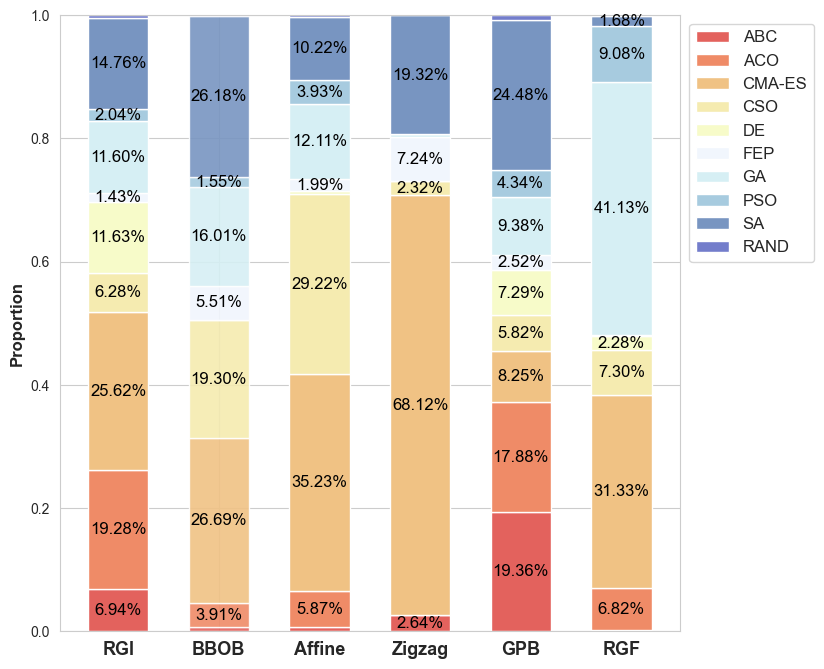

In [23]:
# 两组数据
# 分类标签
labels = ["ABC", "ACO", "CMA-ES", "CSO", "DE", "FEP", "GA", "PSO", "SA",'RAND']
# colors = ["#A39E93", "#CFC8B3", "#D6CFC4", "#B8B0A1", "#E5D8C3", 
#           "#A7B1A5", "#B5ACA1", "#C4B7A6", "#D8CFC1", "#9C8F7C"]
colors=["#E3625D", "#EF8B67", "#F0C284", "#F5EBB0", "#F7FBC9", 
          "#F1F6FD", "#D6EFF4", "#A7CBDF", "#7895C1", "#737DCB"]
cmap = plt.get_cmap('Set1',6)  # 使用 'Set1' 颜色映射，有较大的颜色差别
# 计算堆叠的底部位置
cumulative_data1 = np.cumsum([0] + RGI_label[:-1])
cumulative_data2 = np.cumsum([0] + BBOB_label[:-1])
cumulative_data3 = np.cumsum([0] + Affine_label[:-1])
cumulative_data4 = np.cumsum([0] + Zigzag_label[:-1])
cumulative_data5 = np.cumsum([0] + GPB_label[:-1])
cumulative_data6 = np.cumsum([0] + RGF_label[:-1])

# 创建图形
plt.figure(figsize=(8, 8))

width=0.6
# 绘制第一个堆叠柱
for i in range(len(RGI_label)):
    plt.bar(1, RGI_label[i], bottom=cumulative_data1[i], label=f'{labels[i]}',width=width,alpha=1,color=colors[i])
    if RGI_label[i]<0.01:
        continue
    plt.text(1, cumulative_data1[i] + RGI_label[i]/2, f'{RGI_label[i]*100:.2f}%', ha='center', va='center', color='black',fontsize=12)


for i in range(len(BBOB_label)):
    plt.bar(2, BBOB_label[i], bottom=cumulative_data2[i],width=width,alpha=0.9,color=colors[i])
    if BBOB_label[i]<0.01:
        continue
    plt.text(2, cumulative_data2[i] + BBOB_label[i]/2, f'{BBOB_label[i]*100:.2f}%', ha='center', va='center', color='black',fontsize=12)

for i in range(len(Affine_label)):
    plt.bar(3, Affine_label[i], bottom=cumulative_data3[i],width=width,alpha=1,color=colors[i])
    if Affine_label[i]<0.01:
        continue
    plt.text(3, cumulative_data3[i] + Affine_label[i]/2, f'{Affine_label[i]*100:.2f}%', ha='center', va='center', color='black',fontsize=12)

for i in range(len(Zigzag_label)):
    plt.bar(4, Zigzag_label[i], bottom=cumulative_data4[i],width=width,alpha=1,color=colors[i])
    if Zigzag_label[i]<0.01:
        continue
    plt.text(4, cumulative_data4[i] + Zigzag_label[i]/2, f'{Zigzag_label[i]*100:.2f}%', ha='center', va='center', color='black',fontsize=12)

for i in range(len(GPB_label)):
    plt.bar(5, GPB_label[i], bottom=cumulative_data5[i],width=width,alpha=1,color=colors[i])
    if GPB_label[i]<0.01:
        continue
    plt.text(5, cumulative_data5[i] + GPB_label[i]/2, f'{GPB_label[i]*100:.2f}%', ha='center', va='center', color='black',fontsize=12)
    
for i in range(len(RGF_label)):
    plt.bar(6, RGF_label[i], bottom=cumulative_data6[i],width=width,alpha=1,color=colors[i])
    if RGF_label[i]<0.01:
        continue
    plt.text(6, cumulative_data6[i] + RGF_label[i]/2, f'{RGF_label[i]*100:.2f}%', ha='center', va='center', color='black',fontsize=12)
# 设置图表信息
plt.ylabel('Proportion', fontweight='bold',fontsize=12)
# plt.title('Stacked Bar Chart for Two Datasets')
plt.xticks([1,2,3,4,5,6], ['RGI', 'BBOB', 'Affine', 'Zigzag', 'GPB','RGF'], fontweight='bold',fontsize=13)  # 设置x轴刻度

plt.legend(loc='upper right', bbox_to_anchor=(1.23, 1),fontsize=12)  # 图例放在右侧
plt.savefig("AnalyseLabel.pdf", format='pdf', transparent=True,dpi=500,bbox_inches = 'tight')


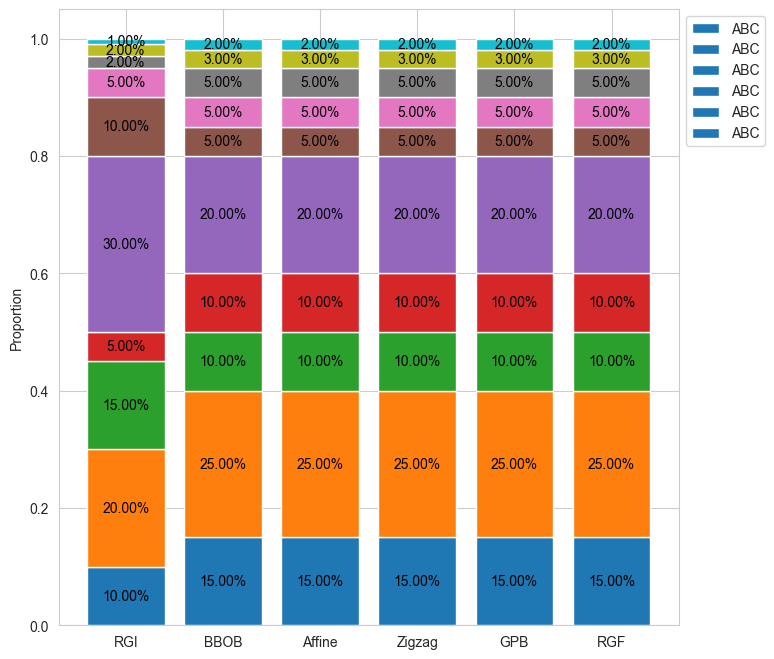

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# 示例数据
RGI_label = [0.1, 0.2, 0.15, 0.05, 0.3, 0.1, 0.05, 0.02, 0.02, 0.01]
BBOB_label = [0.15, 0.25, 0.1, 0.1, 0.2, 0.05, 0.05, 0.05, 0.03, 0.02]
labels = ["ABC", "ACO", "CMA-ES", "CSO", "DE", "FEP", "GA", "PSO", "SA",'RAND']

# 计算堆叠的底部位置
cumulative_data1 = np.cumsum([0] + RGI_label[:-1])
cumulative_data2 = np.cumsum([0] + BBOB_label[:-1])

# 创建图形
plt.figure(figsize=(8, 8))

# 绘制第一个堆叠柱 (RGI)
for i in range(len(RGI_label)):
    plt.bar(1, RGI_label[i], bottom=cumulative_data1[i], label=f'{labels[i]}' if i == 0 else "")
    plt.text(1, cumulative_data1[i] + RGI_label[i]/2, f'{RGI_label[i]*100:.2f}%', ha='center', va='center', color='black')

# 绘制第二个堆叠柱 (BBOB)
for i in range(len(BBOB_label)):
    plt.bar(2, BBOB_label[i], bottom=cumulative_data2[i], label=f'{labels[i]}' if i == 0 else "")
    plt.text(2, cumulative_data2[i] + BBOB_label[i]/2, f'{BBOB_label[i]*100:.2f}%', ha='center', va='center', color='black')

# 你可以添加更多组数据，以下为示例
# 假设后续几组数据均与BBOB_label相同
for group in range(3, 7):  # 从3到6列
    for i in range(len(BBOB_label)):
        plt.bar(group, BBOB_label[i], bottom=cumulative_data2[i], label=f'{labels[i]}' if i == 0 else "")
        plt.text(group, cumulative_data2[i] + BBOB_label[i]/2, f'{BBOB_label[i]*100:.2f}%', ha='center', va='center', color='black')

# 设置图表信息
plt.ylabel('Proportion')
plt.xticks([1,2,3,4,5,6], ['RGI', 'BBOB', 'Affine', 'Zigzag', 'GPB','RGF'])  # 设置x轴刻度
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))  # 图例放在右侧

# 显示图形
plt.show()


In [88]:
part=10
d1=RGI_ela[::part,np.array(list(range(47))+list(range(53,61))+list(range(47,53)))]
a=np.sum(np.abs(RGF_ela) > 30, axis=1) == 0
b=np.sum(np.abs(RGF_ela) >20, axis=1) == 0
d2=RGF_ela[np.array(np.array(a,dtype=np.int8)-np.array(b,dtype=np.int8),dtype=np.bool_)]
d3=GPB_ela[::]
d4=Zigzag_ela[::]
d5=Affine_ela[::]
d6=BBOB_ela[::]

In [83]:
np.sum(np.sum(np.abs(RGF_ela) >20, axis=1) == 0)

33157

In [89]:
data=np.append(d1, d2, axis=0)
data=np.append(data, d3, axis=0)
data=np.append(data, d4, axis=0)
data=np.append(data, d5, axis=0)
data=np.append(data, d6, axis=0)
c=np.zeros(len(data),dtype=np.int8)
c[len(d1):]+=1
c[len(d1)+len(d2):]+=1
c[len(d1)+len(d2)+len(d3):]+=1
c[len(d1)+len(d2)+len(d3)+len(d4):]+=1
c[len(d1)+len(d2)+len(d3)+len(d4)+len(d5):]+=1
ind=[0,len(d1),len(d1)+len(d2),len(d1)+len(d2)+len(d3),len(d1)+len(d2)+len(d3)+len(d4),len(d1)+len(d2)+len(d3)+len(d4)+len(d5),len(d1)+len(d2)+len(d3)+len(d4)+len(d5)+len(d6)]

In [17]:
import seaborn as sns
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# # 初始化UMAP模型
# umap_model = umap.UMAP(min_dist=0.8)
# # 使用UMAP进行降维
# low_dim_data = umap_model.fit_transform(data[:,:],)

from sklearn.manifold import TSNE
for i in range(61):
    data[:,i]=(data[:,i]-np.min(data[:,i]))/(np.max(data[:,i])-np.min(data[:,i]))
tsne = TSNE(n_components=2, random_state=0)
low_dim_data = tsne.fit_transform(data[:,:],)


KeyboardInterrupt



In [90]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
for i in range(61):
    data[:,i]=(data[:,i]-np.min(data[:,i]))/(np.max(data[:,i])-np.min(data[:,i]))
low_dim_data = pca.fit_transform(data)


C:\Users\Guo\AppData\Local\Temp\ipykernel_29968\1280142863.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=cmap(i), label=benchmarks[i])


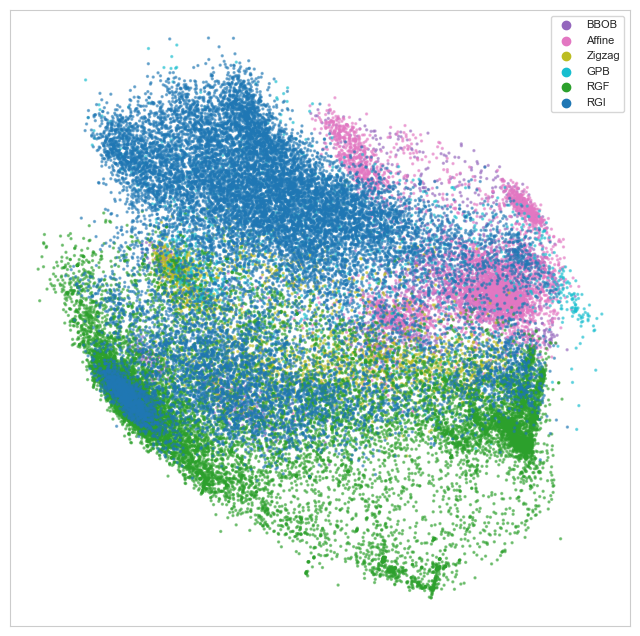

In [91]:
# 绘图
from matplotlib.colors import ListedColormap
markers=['o','D','^','v','*','+']

benchmarks=['RGI','RGF','GPB','Zigzag','Affine','BBOB']
plt.figure(figsize=(8, 8))
colors = [[0.12156862745098039,0.4666666666666667,0.7058823529411765,1.0],
[0.17254901960784313,0.6274509803921569,0.17254901960784313,1.0],
[0.09019607843137255,0.7450980392156863,0.8117647058823529,1.0],
[0.7372549019607844,0.7411764705882353,0.13333333333333333,1.0],
[0.8901960784313725,0.4666666666666667,0.7607843137254902,1.0],
[0.5803921568627451,0.403921568627451,0.7411764705882353,1.0]
]
cmap = ListedColormap(colors)

plt.scatter(low_dim_data[::-1, 0], low_dim_data[::-1, 1], c=c[::-1],alpha =0.5,cmap=cmap,s=2)
for i in range(5,-1,-1):

    plt.scatter([], [], c=cmap(i), label=benchmarks[i])

plt.legend(loc="upper right",fontsize=8)
# 去掉网格
plt.grid(False)
# 去掉 x 轴和 y 轴的刻度
plt.xticks([])
plt.yticks([])

# plt.colorbar()
plt.savefig("AnalyseFeatureSpace.pdf", format='pdf', transparent=True,dpi=500)
# plt.show()

In [37]:
# 用方差来对比特征空间的大小
d1=RGI_ela[::,np.array(list(range(47))+list(range(53,61))+list(range(47,53)))]
d2=RGF_ela[::]
d3=BBOB_ela[:]
d4=Affine_ela[:]
d5=Zigzag_ela[:]
d6=GPB_ela[:]
d7=MA_ela[:]
data=np.append(d1, d2, axis=0)
data=np.append(data, d3, axis=0)
data=np.append(data, d4, axis=0)
data=np.append(data, d5, axis=0)
data=np.append(data, d6, axis=0)
data=np.append(data, d7, axis=0)
ds=[d1,d2,d3,d4,d5,d6,d7]
SumStd=[0,0,0,0,0,0,0]
for i in range(61):
    Vmin=np.min(data[:,i])
    Vmax=np.max(data[:,i])
    # Vmean=np.mean(data[:,i])
    # Vstd=np.std(data[:,i])
    for j in range(7):
        ds[j][:,i]=(ds[j][:,i]-Vmin)/(Vmax-Vmin)
        # ds[j][:,i]=(ds[j][:,i]-Vmean)/Vstd
        SumStd[j]+=np.std(ds[j][:,i])

In [12]:
SumStd=[5.83276303162467, 4.8966139385210345, 3.5930985927445502, 2.712274609599916, 3.2652669930091474, 4.744090929595938, 1.9809565541056222]